## Lotka - Voltera system

###  Imports and Data Loading

In [1]:
!pip install torchdiffeq

In [17]:
import numpy as np
import torch
import torch.nn as nn
from torchdiffeq import odeint
import matplotlib.pyplot as plt

In [18]:
def lotka_volterra(t, y, alpha=1.0, beta=0.1, gamma=1.5, delta=0.075):
    """Lotka-Volterra predator-prey model."""
    rabbits, wolves = y
    drabbits_dt = alpha * rabbits - beta * rabbits * wolves
    dwolves_dt = delta * rabbits * wolves - gamma * wolves
    return torch.tensor([drabbits_dt, dwolves_dt], dtype=y.dtype)

# Generate synthetic data
t_train = torch.linspace(0, 25, 1000)
y0 = torch.tensor([10.0, 5.0], dtype=torch.float64)  # Initial populations
y_train = odeint(lotka_volterra, y0, t_train)

# Convert to numpy for plotting
t_np = t_train.numpy()
y_np = y_train.numpy()

print(f"Time shape: {t_np.shape}")
print(f"States shape: {y_np.shape}")

Time shape: (1000,)
States shape: (1000, 2)


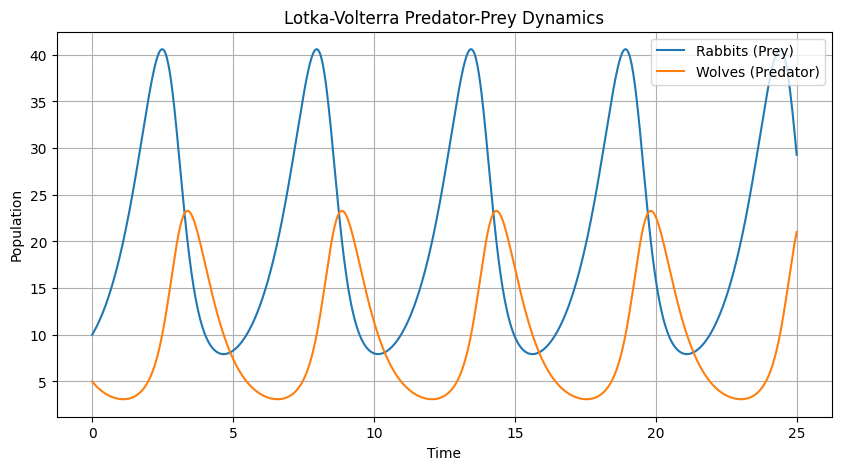

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(t_np, y_np[:, 0], label='Rabbits (Prey)')
plt.plot(t_np, y_np[:, 1], label='Wolves (Predator)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Lotka-Volterra Predator-Prey Dynamics')
plt.legend()
plt.grid(True)
plt.show()

### Define the Neural ODE Model


In [36]:
class NeuralODE(nn.Module):

    def __init__(self, n_states=2, hidden_width=64):
        super(NeuralODE, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(n_states, hidden_width),
            nn.SiLU(),
            nn.Linear(hidden_width, hidden_width),
            nn.SiLU(),
            nn.Linear(hidden_width, n_states)
        )

    def ode_func(self, t, y):

        return self.net(y)

    def forward(self, y0, t):

        return odeint(self.ode_func, y0, t)


model = NeuralODE(n_states=2, hidden_width=24)

model = model.double()
print(model)


NeuralODE(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=24, bias=True)
    (1): SiLU()
    (2): Linear(in_features=24, out_features=24, bias=True)
    (3): SiLU()
    (4): Linear(in_features=24, out_features=2, bias=True)
  )
)


### Test the Untrained Model

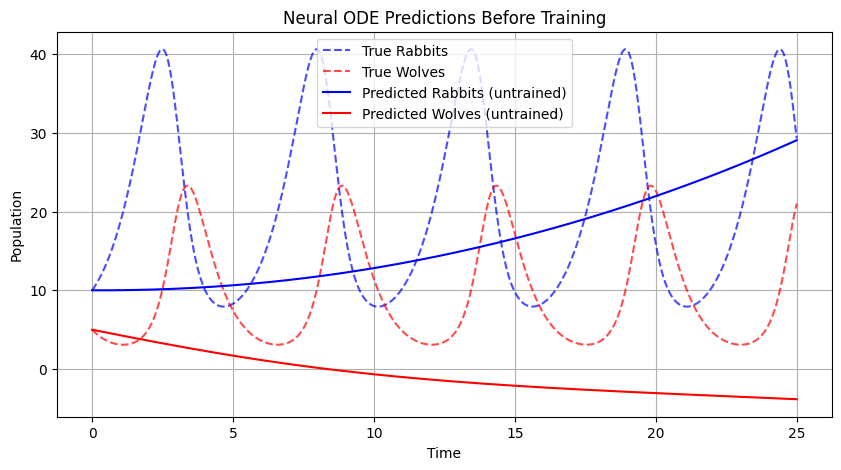

In [37]:
y0_train = y_train[0]  # First time point

# Make prediction with untrained model
model.eval()
with torch.no_grad():
    y_pred = model(y0_train, t_train)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(t_np, y_np[:, 0], 'b--', label='True Rabbits', alpha=0.7)
plt.plot(t_np, y_np[:, 1], 'r--', label='True Wolves', alpha=0.7)
plt.plot(t_np, y_pred[:, 0], 'b-', label='Predicted Rabbits (untrained)')
plt.plot(t_np, y_pred[:, 1], 'r-', label='Predicted Wolves (untrained)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Neural ODE Predictions Before Training')
plt.legend()
plt.grid(True)
plt.show()


### Training Loop

In [38]:
def train_step(model, y0, t_true, y_true, optimizer, loss_fn):
    model.train()
    optimizer.zero_grad()

    y_pred = model(y0, t_true)

    loss = loss_fn(y_pred, y_true)

    loss.backward()
    optimizer.step()

    return loss.item()

In [39]:
# Set up training parameters
n_epochs = 200
learning_rate = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()
loss_history = []

### Stage 1

In [40]:
t_stage1 = t_train[:250]
y_stage1 = y_train[:250]

for epoch in range(500):
    loss = train_step(model, y0_train, t_stage1, y_stage1, optimizer, loss_fn)
    loss_history.append(loss)
    if (epoch + 1) % 10 == 0:
        print(f"Stage 1 - Epoch {epoch+1}, Loss: {loss:.6f}")

Stage 1 - Epoch 10, Loss: 125.569188
Stage 1 - Epoch 20, Loss: 111.489062
Stage 1 - Epoch 30, Loss: 107.927367
Stage 1 - Epoch 40, Loss: 107.752827
Stage 1 - Epoch 50, Loss: 106.618244
Stage 1 - Epoch 60, Loss: 105.809603
Stage 1 - Epoch 70, Loss: 104.492158
Stage 1 - Epoch 80, Loss: 102.189151
Stage 1 - Epoch 90, Loss: 98.412938
Stage 1 - Epoch 100, Loss: 92.753003
Stage 1 - Epoch 110, Loss: 84.987114
Stage 1 - Epoch 120, Loss: 75.925727
Stage 1 - Epoch 130, Loss: 66.945628
Stage 1 - Epoch 140, Loss: 58.830704
Stage 1 - Epoch 150, Loss: 53.148787
Stage 1 - Epoch 160, Loss: 48.725247
Stage 1 - Epoch 170, Loss: 45.262818
Stage 1 - Epoch 180, Loss: 42.378306
Stage 1 - Epoch 190, Loss: 40.269218
Stage 1 - Epoch 200, Loss: 38.301705
Stage 1 - Epoch 210, Loss: 36.740995
Stage 1 - Epoch 220, Loss: 35.262713
Stage 1 - Epoch 230, Loss: 33.898731
Stage 1 - Epoch 240, Loss: 32.562839
Stage 1 - Epoch 250, Loss: 31.327320
Stage 1 - Epoch 260, Loss: 30.120284
Stage 1 - Epoch 270, Loss: 28.957940
St

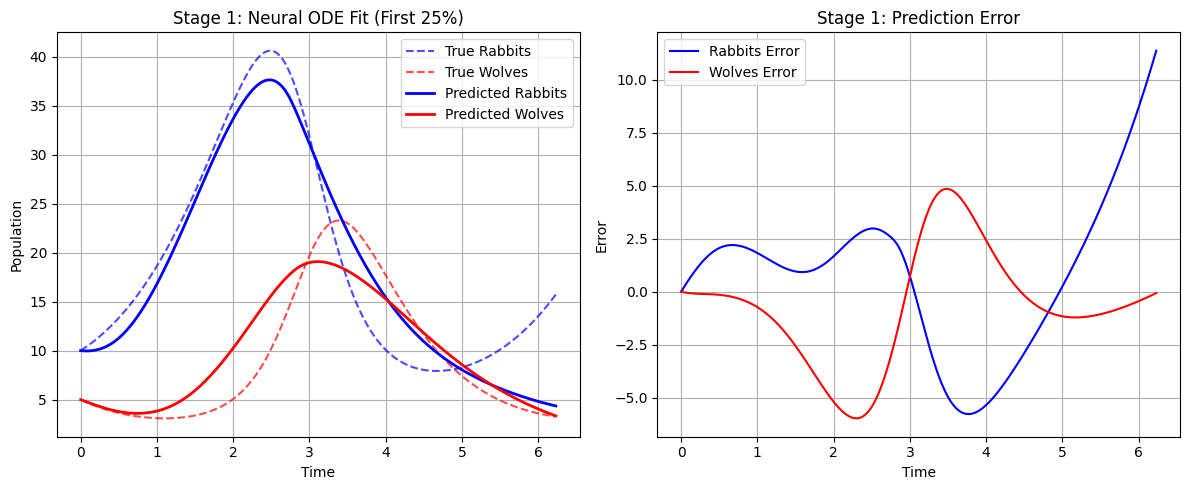

In [41]:

model.eval()

with torch.no_grad():

    y_pred_stage1 = model(y0_train, t_stage1)


t_stage1_np = t_stage1.numpy()
y_stage1_np = y_stage1.numpy()
y_pred_stage1_np = y_pred_stage1.numpy()


plt.figure(figsize=(12, 5))

# ---- Population Plot ----
plt.subplot(1, 2, 1)
plt.plot(t_stage1_np, y_stage1_np[:, 0], 'b--', label='True Rabbits', alpha=0.7)
plt.plot(t_stage1_np, y_stage1_np[:, 1], 'r--', label='True Wolves', alpha=0.7)

plt.plot(t_stage1_np, y_pred_stage1_np[:, 0], 'b-', label='Predicted Rabbits', linewidth=2)
plt.plot(t_stage1_np, y_pred_stage1_np[:, 1], 'r-', label='Predicted Wolves', linewidth=2)

plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Stage 1: Neural ODE Fit (First 25%)')
plt.legend()
plt.grid(True)

# ---- Error Plot ----
plt.subplot(1, 2, 2)
plt.plot(t_stage1_np, y_stage1_np[:, 0] - y_pred_stage1_np[:, 0], 'b-', label='Rabbits Error')
plt.plot(t_stage1_np, y_stage1_np[:, 1] - y_pred_stage1_np[:, 1], 'r-', label='Wolves Error')

plt.xlabel('Time')
plt.ylabel('Error')
plt.title('Stage 1: Prediction Error')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Stage 2

In [42]:
t_stage2 = t_train[:500]
y_stage2 = y_train[:500]

for epoch in range(500):
    loss = train_step(model, y0_train, t_stage2, y_stage2, optimizer, loss_fn)
    loss_history.append(loss)
    if (epoch + 1) % 10 == 0:
        print(f"Stage 2 - Epoch {epoch+1}, Loss: {loss:.6f}")


Stage 2 - Epoch 10, Loss: 124.760443
Stage 2 - Epoch 20, Loss: 89.167840
Stage 2 - Epoch 30, Loss: 31.520479
Stage 2 - Epoch 40, Loss: 20.906180
Stage 2 - Epoch 50, Loss: 15.250837
Stage 2 - Epoch 60, Loss: 13.193891
Stage 2 - Epoch 70, Loss: 12.607142
Stage 2 - Epoch 80, Loss: 11.953787
Stage 2 - Epoch 90, Loss: 11.610069
Stage 2 - Epoch 100, Loss: 11.289194
Stage 2 - Epoch 110, Loss: 11.049237
Stage 2 - Epoch 120, Loss: 10.842355
Stage 2 - Epoch 130, Loss: 10.654986
Stage 2 - Epoch 140, Loss: 10.482958
Stage 2 - Epoch 150, Loss: 10.321500
Stage 2 - Epoch 160, Loss: 10.168142
Stage 2 - Epoch 170, Loss: 10.020874
Stage 2 - Epoch 180, Loss: 9.878418
Stage 2 - Epoch 190, Loss: 9.739848
Stage 2 - Epoch 200, Loss: 9.604453
Stage 2 - Epoch 210, Loss: 9.471702
Stage 2 - Epoch 220, Loss: 9.341188
Stage 2 - Epoch 230, Loss: 9.212589
Stage 2 - Epoch 240, Loss: 9.085655
Stage 2 - Epoch 250, Loss: 8.960176
Stage 2 - Epoch 260, Loss: 8.835988
Stage 2 - Epoch 270, Loss: 8.712964
Stage 2 - Epoch 280

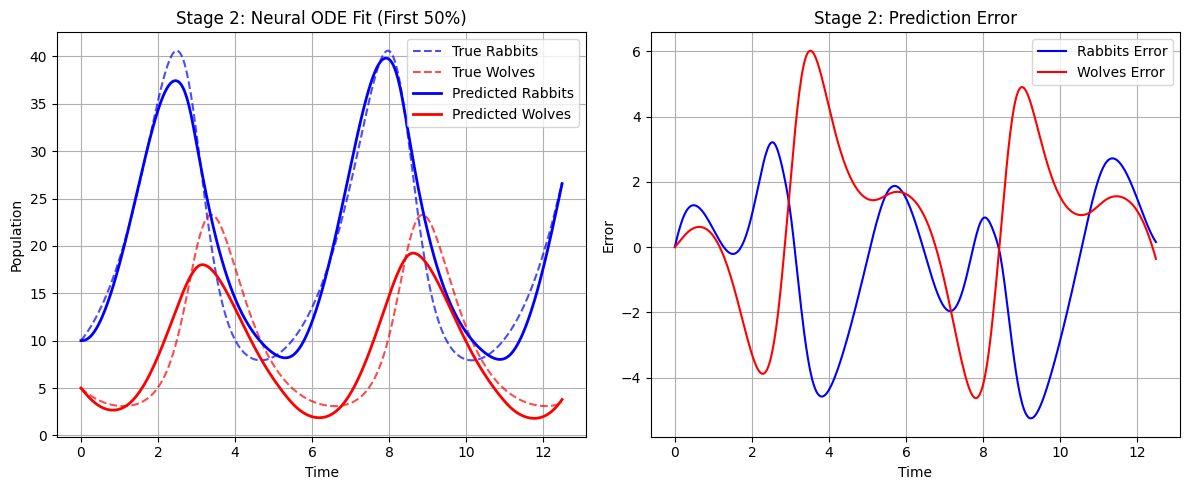

In [43]:

model.eval()

with torch.no_grad():

    y_pred_stage2 = model(y0_train, t_stage2)


t_stage2_np = t_stage2.numpy()
y_stage2_np = y_stage2.numpy()
y_pred_stage2_np = y_pred_stage2.numpy()


plt.figure(figsize=(12, 5))

# ---- Population Plot ----
plt.subplot(1, 2, 1)
plt.plot(t_stage2_np, y_stage2_np[:, 0], 'b--', label='True Rabbits', alpha=0.7)
plt.plot(t_stage2_np, y_stage2_np[:, 1], 'r--', label='True Wolves', alpha=0.7)

plt.plot(t_stage2_np, y_pred_stage2_np[:, 0], 'b-', label='Predicted Rabbits', linewidth=2)
plt.plot(t_stage2_np, y_pred_stage2_np[:, 1], 'r-', label='Predicted Wolves', linewidth=2)

plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Stage 2: Neural ODE Fit (First 50%)')
plt.legend()
plt.grid(True)

# ---- Error Plot ----
plt.subplot(1, 2, 2)
plt.plot(t_stage2_np, y_stage2_np[:, 0] - y_pred_stage2_np[:, 0], 'b-', label='Rabbits Error')
plt.plot(t_stage2_np, y_stage2_np[:, 1] - y_pred_stage2_np[:, 1], 'r-', label='Wolves Error')

plt.xlabel('Time')
plt.ylabel('Error')
plt.title('Stage 2: Prediction Error')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Stage 3

In [44]:
for epoch in range(500):
    loss = train_step(model, y0_train, t_train, y_train, optimizer, loss_fn)
    loss_history.append(loss)
    if (epoch + 1) % 10 == 0:
        print(f"Stage 3 - Epoch {epoch+1}, Loss: {loss:.6f}")

print("Training complete!")

Stage 3 - Epoch 10, Loss: 9.929770
Stage 3 - Epoch 20, Loss: 6.319904
Stage 3 - Epoch 30, Loss: 6.511494
Stage 3 - Epoch 40, Loss: 6.081089
Stage 3 - Epoch 50, Loss: 5.980576
Stage 3 - Epoch 60, Loss: 5.876741
Stage 3 - Epoch 70, Loss: 5.787532
Stage 3 - Epoch 80, Loss: 5.703466
Stage 3 - Epoch 90, Loss: 5.622510
Stage 3 - Epoch 100, Loss: 5.541545
Stage 3 - Epoch 110, Loss: 5.461904
Stage 3 - Epoch 120, Loss: 5.382563
Stage 3 - Epoch 130, Loss: 5.303717
Stage 3 - Epoch 140, Loss: 5.225346
Stage 3 - Epoch 150, Loss: 5.147415
Stage 3 - Epoch 160, Loss: 5.069935
Stage 3 - Epoch 170, Loss: 4.992909
Stage 3 - Epoch 180, Loss: 4.916347
Stage 3 - Epoch 190, Loss: 4.840263
Stage 3 - Epoch 200, Loss: 4.764652
Stage 3 - Epoch 210, Loss: 4.689523
Stage 3 - Epoch 220, Loss: 4.614896
Stage 3 - Epoch 230, Loss: 4.540773
Stage 3 - Epoch 240, Loss: 4.467167
Stage 3 - Epoch 250, Loss: 4.394085
Stage 3 - Epoch 260, Loss: 4.321543
Stage 3 - Epoch 270, Loss: 4.249538
Stage 3 - Epoch 280, Loss: 4.178092
S

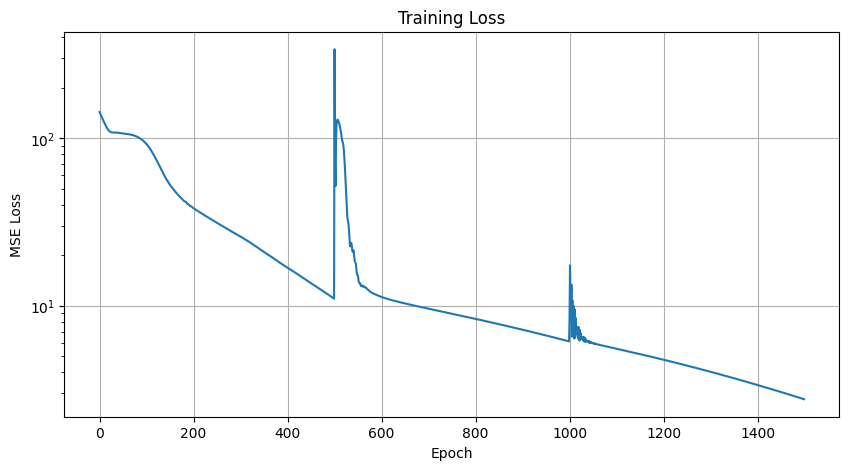

In [45]:
# Plot loss history
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.yscale('log')
plt.grid(True)
plt.show()

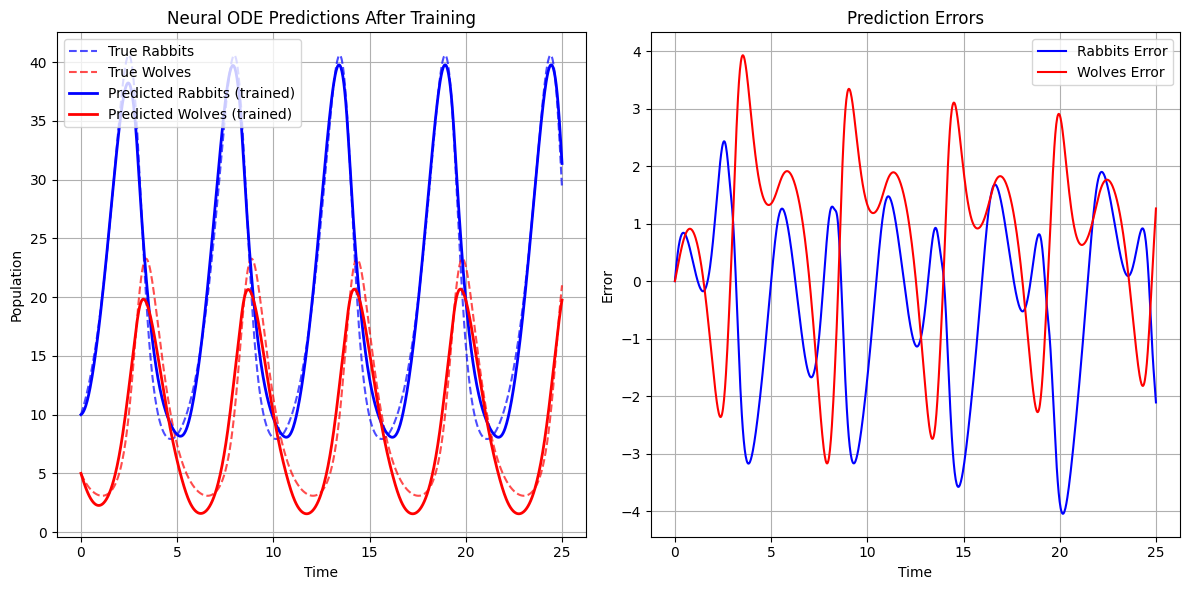

In [46]:
model.eval()
with torch.no_grad():
    y_pred_trained = model(y0_train, t_train)

# Plot final results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(t_np, y_np[:, 0], 'b--', label='True Rabbits', alpha=0.7)
plt.plot(t_np, y_np[:, 1], 'r--', label='True Wolves', alpha=0.7)
plt.plot(t_np, y_pred_trained[:, 0], 'b-', label='Predicted Rabbits (trained)', linewidth=2)
plt.plot(t_np, y_pred_trained[:, 1], 'r-', label='Predicted Wolves (trained)', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Neural ODE Predictions After Training')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_np, y_np[:, 0] - y_pred_trained[:, 0].numpy(), 'b-', label='Rabbits Error')
plt.plot(t_np, y_np[:, 1] - y_pred_trained[:, 1].numpy(), 'r-', label='Wolves Error')
plt.xlabel('Time')
plt.ylabel('Error')
plt.title('Prediction Errors')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Extrapolation Test

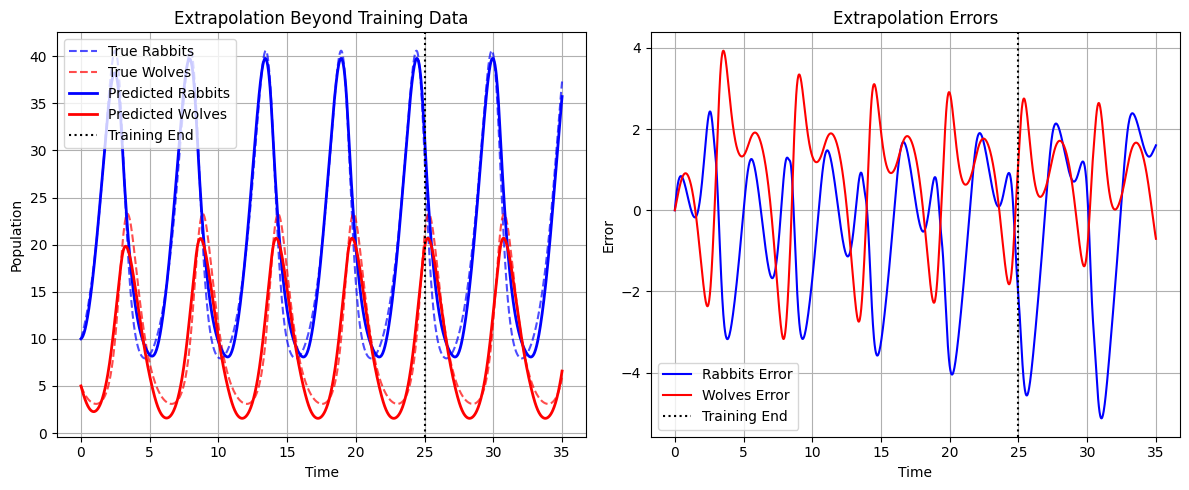

In [47]:
t_extrapolate = torch.linspace(0, 35, 1400)  # Go further than training data
y_test = odeint(lotka_volterra, y0_train, t_extrapolate)

# Make predictions with trained model
with torch.no_grad():
    y_pred_extrapolate = model(y0_train, t_extrapolate)

# Plot extrapolation results
t_extrap_np = t_extrapolate.numpy()
y_test_np = y_test.numpy()
y_pred_extrap_np = y_pred_extrapolate.numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_extrap_np, y_test_np[:, 0], 'b--', label='True Rabbits', alpha=0.7)
plt.plot(t_extrap_np, y_test_np[:, 1], 'r--', label='True Wolves', alpha=0.7)
plt.plot(t_extrap_np, y_pred_extrap_np[:, 0], 'b-', label='Predicted Rabbits', linewidth=2)
plt.plot(t_extrap_np, y_pred_extrap_np[:, 1], 'r-', label='Predicted Wolves', linewidth=2)
plt.axvline(x=t_np[-1], color='k', linestyle=':', label='Training End')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Extrapolation Beyond Training Data')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_extrap_np, y_test_np[:, 0] - y_pred_extrap_np[:, 0], 'b-', label='Rabbits Error')
plt.plot(t_extrap_np, y_test_np[:, 1] - y_pred_extrap_np[:, 1], 'r-', label='Wolves Error')
plt.axvline(x=t_np[-1], color='k', linestyle=':', label='Training End')
plt.xlabel('Time')
plt.ylabel('Error')
plt.title('Extrapolation Errors')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()